In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import matplotlib.gridspec as gridspec
import os

os.chdir("..")

from dirdet.config.targets import FLUORINE as Fl
from dirdet.config.physics import GALACTIC

from dirdet.wimp_rates import dRdEdO_WIMP, dRdE_WIMP
from dirdet.helpers import wimp_max_recoil

x_pix_resolution = "16"

# Introduction

The directional calculation of WIMP recoil rates is simpler than the neutrino counterpart. We define the recoil vector $\hat{\mathbf{q}}$ such that $\cos{\theta}=\mathbf{v}\cdot\hat{\mathbf{q}}/v_{\text{min}}$ and use this to get the *Radon Transform* of the velocity distribution,
$$\hat{f}(v_{min},\hat{\mathbf{q}}) = \int{\delta(\mathbf{v}\cdot\mathbf{\hat{q}}-v_{min})f(\mathbf{v} + \mathbf{v}_{\text{lab}})d^3\mathbf{v}}
$$
Essentially, we're integrating over all velocities that lie in a plane perpendicular to $\hat{\mathbf{q}}$ at a distance $v_{\text{min}}$ from the origin. In out plot we use an array of recoil vectors, representing an equal angular area discretisation of the
sky generated thorugh `HEALPix`. The arrays are saved in `input_data/HEALPix`, and were provided to me by my supervisor. Using arrays with more entires allows for smoother plots.

For the Maxwell-Boltzman distribution of the SHM, the Radon transform has the analytical solution, 
$$
\hat{f}_{\text{SHM}}(v_{\text{min}}\hat{\mathbf{q}})=
\begin{cases}
\exp\left( \frac{|v_{\text{min}}|+\hat{\mathbf{q}}\cdot \mathbf{\hat{v}}_{\text{lab}}}{2\sigma^{2}_{v}}\right) -\exp\left( -\frac{v_{\text{esc}}^{2}}{2\sigma^{2}_{v}} \right) 
& \text{if } v_{\text{min}} + \hat{\mathbf{q}}\cdot \hat{\mathbf{v}} < v_{\text{esc}} \\
0 & \text{if } v_{\text{min}}+\mathbf{\hat{q}} \cdot \mathbf{\hat{v}} \geq v_{\text{esc}}
\end{cases}
$$

This then allows us to define the direcitonal WIMP differential recoil rate as,
$$
\frac{d^{2}R}{dE_{r}d\Omega_{r}} = \frac{\rho_{0}}{4\pi \mu^{2}_{\chi p}m_{\chi}}\sigma_{p}A^{2}F^{2}(E_{r})\hat{f}(v_{\text{min}},\mathbf{\hat{q}})
$$


# Parameters

In [2]:
# parameters
m_arr = [8.0, 12.0, 60.0, 150]
sig_arr = [5*1e-45, 2*1e-47, 1e-48, 4*1e-48]

params_ls = [(m,s) for m,s in zip(m_arr,sig_arr)]
E_r = np.geomspace(1e-3,1e3,1000)

q = np.loadtxt(f"input_data/xpix/xpix{x_pix_resolution}.txt",unpack=False)  # recoil vectors
q_lab = np.array([0,1,0]) #WIMP
cos_theta_arr = np.dot(q,q_lab)

del_omega = 4*np.pi/q_lab.shape[0]

x_lab = np.array([0,1,0])
v_lab = GALACTIC.V_LAB * x_lab

# Recoil Rate as a Function of $E_r$ and $\cos{\theta_{\chi}}$ 

We define the angle $\cos{\theta_{\chi}}=\hat{\mathbf{q}} \cdot \hat{\mathbf{q}}_v$ as the angle between the recoiling vector, and the unit vector corresponding to the direction of $v_{\text{lab}}$. Followig simple kinematic principles, we should expect to see the highest recoil rate when these vectors are pointint in opposite directions, representing a "head-on" collision, conciding with the value $\cos{\theta_{\chi}}=-1$. Inversely we should expect to see minimal recoils, when the directions are aligned, conciding with  $\cos{\theta_{\chi}}=1$

Now we will plot the recoil rate as a function of both inputs, for four WIMP parameter pairs ($m_\chi$ [GeV], $\sigma_p$ [$\text{cm}^2$]):
- ($8$, $5\times10^{-45}$)
- ($12, 1.5 \times 10^{-47}$)
- ($60, 10^{-48}$)
- ($150, 4 \times 10^{-48}$)

This will be plotted as a surface plot on the left, and a colour plot on the right.

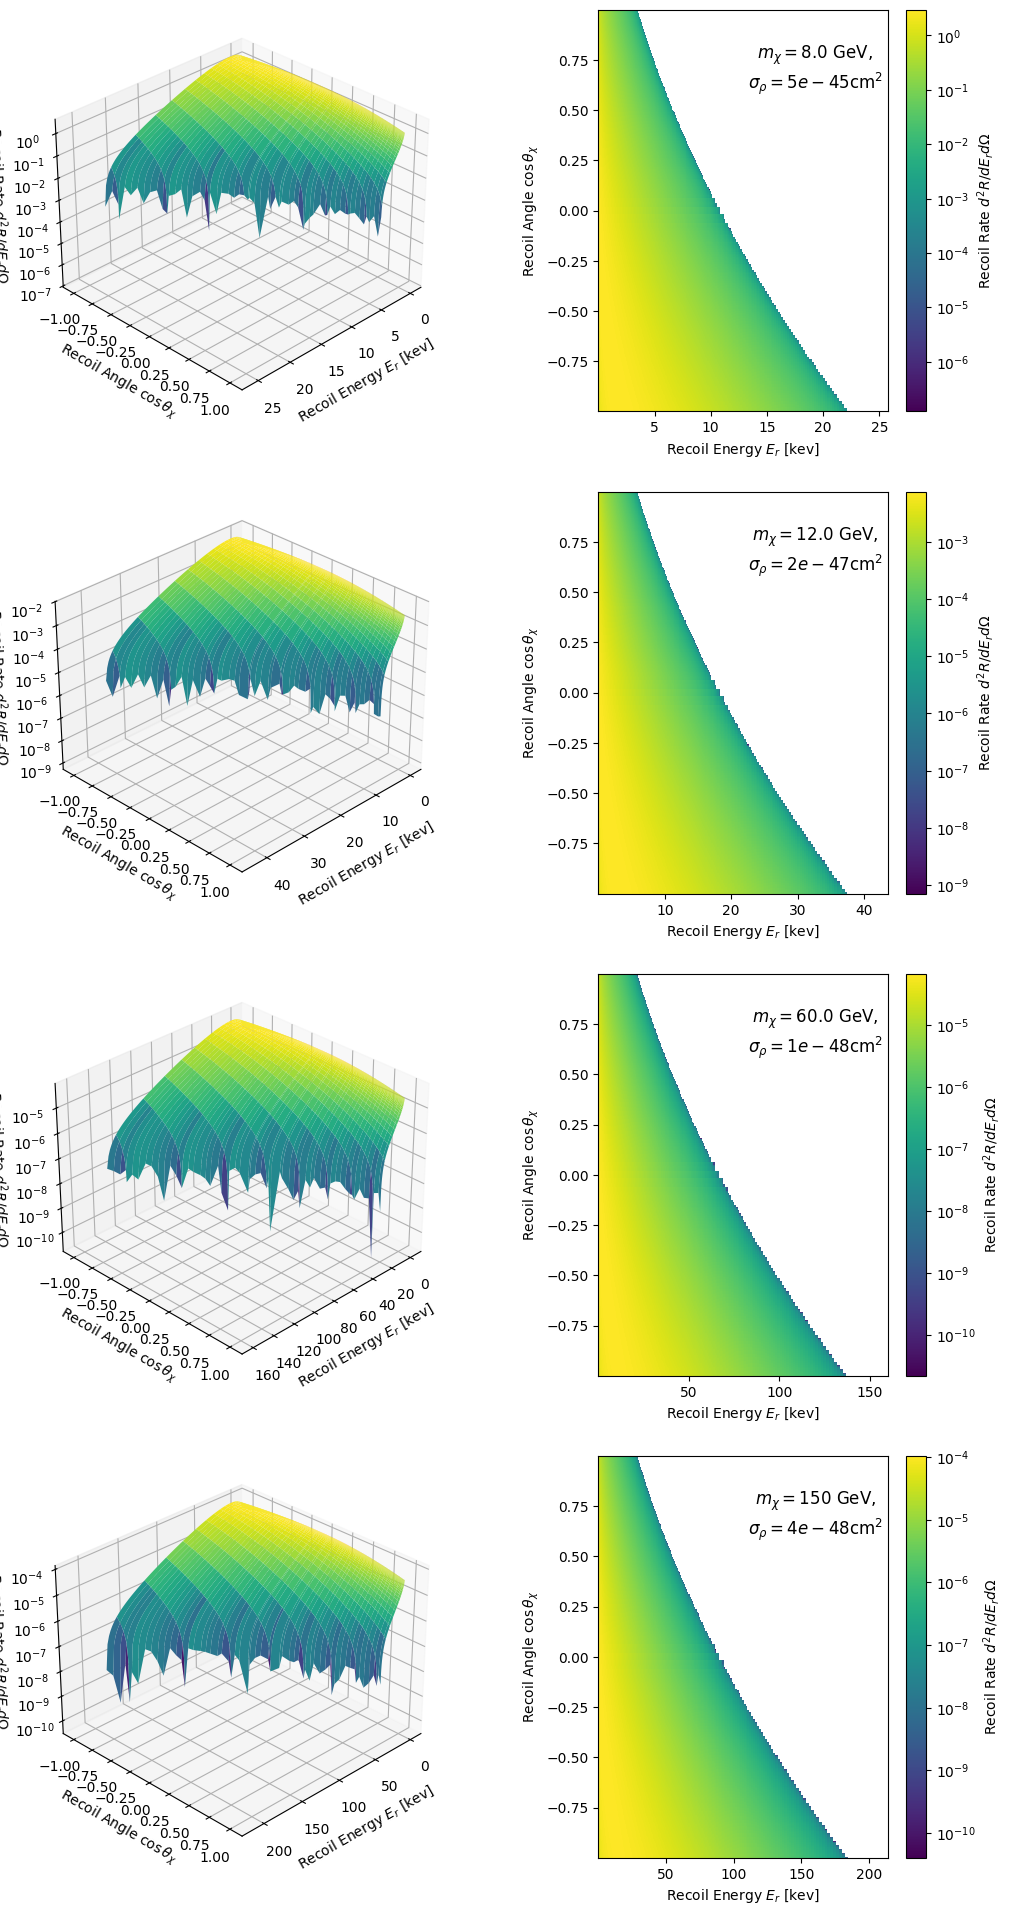

In [3]:
n = len(params_ls)

fig = plt.figure(figsize=(14,6*n))
gs = gridspec.GridSpec(n, 2, width_ratios=[2, 1], wspace=0.0)

sort_idx = np.argsort(cos_theta_arr)

def log_tick_formatter(val, pos):
    return f"$10^{{{val:.0f}}}$"

xlabel = "Recoil Energy $E_r$ [kev]"
ylabel = "Recoil Angle $\\cos{\\theta_{\\chi}}$"
zlabel = "Recoil Rate $d^2R/dE_rd\\Omega$"

for i, params in enumerate(params_ls):
    m_chi, sig_p = params
    # define axis
    ax_left = fig.add_subplot(gs[i, 0], projection='3d')
    ax_right = fig.add_subplot(gs[i, 1])
    ax_right.text(0.75, 0.85, f"$m_\\chi={m_chi}$ GeV,\n$\\sigma_\\rho={sig_p}$cm$^{2}$", transform=ax_right.transAxes, 
            ha='center', va='center', fontsize=12)

    # find max e_r for plotting
    dR = dRdE_WIMP(E_r=E_r, m_chi=m_chi, sigma_p=sig_p, A=Fl.A)
    max_er = wimp_max_recoil(E_r=E_r,dR=dR)
    E_r_plot = np.geomspace(1e-3,max_er,1000)

    # calcualte dir rate
    dR_mat = dRdEdO_WIMP(E_r=E_r_plot, x_pix=q, m_chi=m_chi, sigma_p=sig_p, A=Fl.A, v_lab=v_lab)
    dR_safe = np.where(dR_mat > 0, dR_mat, np.nan)[sort_idx,:]
    energy, angles = np.meshgrid(E_r_plot,cos_theta_arr[sort_idx])

    # colour plot
    mesh = ax_right.pcolormesh(energy, angles, np.log10(dR_safe), cmap="viridis")
    cbar = fig.colorbar(mesh, ax=ax_right)

    # colour plot formatting
    ax_right.set_xlabel(xlabel), ax_right.set_ylabel(ylabel)
    cbar.set_label(zlabel)
    cbar.ax.yaxis.set_major_formatter(FuncFormatter(log_tick_formatter))

    # surf plot
    surf = ax_left.plot_surface(energy,angles,np.log10(dR_safe),cmap="viridis")
    
    # formatting
    ax_left.set_xlabel(xlabel), ax_left.set_ylabel(ylabel), ax_left.set_zlabel(zlabel)
    ax_left.zaxis.set_major_formatter(FuncFormatter(log_tick_formatter))

    ax_left.view_init(elev=30, azim=45)

    